# Customer Product Review: Sentiment Analysis

### Importing Librires 

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Data Inspection

In [102]:
df = pd.read_csv("245_1.csv")

In [103]:
df.head(3)

,id,brand,categories,dateAdded,dateUpdated,ean,keys,manufacturer,manufacturerNumber,name,...,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,upc
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",2017-07-25T00:52:42Z,2018-02-05T08:36:58Z,6.02537E+11,"602537205981,universalmusic/14331328,universal...",Universal Music Group / Cash Money,14331328,Pink Friday: Roman Reloaded Re-Up (w/dvd),...,NaN,0.0,5,https://redsky.target.com/groot-domain-api/v1/...,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,Joshua,6.02537E+11
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,73416000391,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,100209113.0,NaN,5,https://www.walmart.com/reviews/product/29775278,Good flavor. This review was collected as part...,Good,NaN,NaN,Dorothy W,73416000391
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,73416000391,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,100209113.0,NaN,5,https://www.walmart.com/reviews/product/29775278,Good flavor.,Good,NaN,NaN,Dorothy W,73416000391


In [104]:
df.shape

(71044, 25)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71044 entries, 0 to 71043
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    71044 non-null  object 
 1   brand                 71044 non-null  object 
 2   categories            71044 non-null  object 
 3   dateAdded             71044 non-null  object 
 4   dateUpdated           71044 non-null  object 
 5   ean                   39065 non-null  object 
 6   keys                  71044 non-null  object 
 7   manufacturer          70903 non-null  object 
 8   manufacturerNumber    70841 non-null  object 
 9   name                  71044 non-null  object 
 10  reviews.date          70977 non-null  object 
 11  reviews.dateAdded     71044 non-null  object 
 12  reviews.dateSeen      71044 non-null  object 
 13  reviews.didPurchase   32158 non-null  object 
 14  reviews.doRecommend   60429 non-null  object 
 15  reviews.id         

In [106]:
df.describe(include='object')

,id,brand,categories,dateAdded,dateUpdated,ean,keys,manufacturer,manufacturerNumber,name,...,reviews.dateSeen,reviews.didPurchase,reviews.doRecommend,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,upc
count,71044,71044,71044,71044,71044,39065,71044,70903,70841,71044,...,71044,32158,60429,71044,71008,70567,5410,449,70942,71042
unique,600,392,581,598,354,473,600,463,583,600,...,17469,2,2,22508,64913,42681,2282,52,58087,562
top,AVpf3VOfilAPnD_xjpun,Clorox,"Household Essentials,Cleaning Supplies,Kitchen...",2015-09-11T18:17:13Z,2018-02-05T10:22:44Z,44600015996,"clorox/12992356,044600015996,cloroxdisinfectin...",Clorox,12992356,Clorox Disinfecting Wipes Value Pack Scented 1...,...,2017-09-03T20:43:00.000Z,False,True,https://redsky.target.com/groot-domain-api/v1/...,Good,Great movie,Chicago,CA,An anonymous customer,44600015996
freq,8606,10700,8606,8606,13753,8606,8606,8607,8606,8606,...,1063,28476,55587,196,26,1367,68,40,421,8606


### Data Cleaning

#### Selecting Required Columns:

In [107]:
df = df[['brand','manufacturer','reviews.didPurchase','reviews.rating', 'reviews.text']]

In [108]:
df.duplicated().sum()

np.int64(321)

In [109]:
df = df.drop_duplicates()

In [110]:
df.isnull().sum()

brand                      0
manufacturer             141
reviews.didPurchase    38704
reviews.rating             0
reviews.text              24
dtype: int64

#### Inputing null values on 'reviews.didpurchase' & Removing all the null values:

In [111]:
df["reviews.didPurchase"] = df["reviews.didPurchase"].fillna("Not Avialable")

In [112]:
df = df.dropna()

### Visualizing The Result

#### Review Ratings Distribution: 

In [113]:
data = df["reviews.rating"].value_counts()

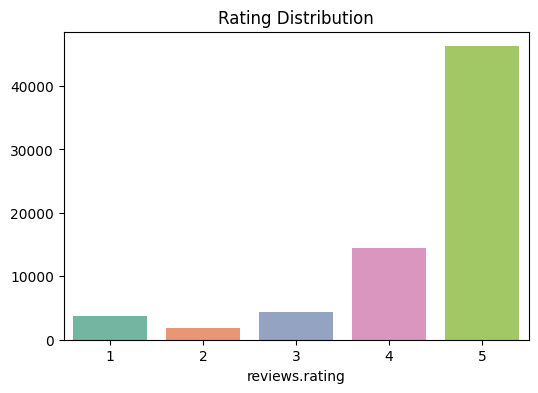

In [114]:
plt.figure(figsize=(6, 4))
sns.barplot(x=data.index, y=data.values,palette='Set2')
plt.title("Rating Distribution")
plt.show()

In [115]:
## Need to map 1,2 - Unhappy, 3-OK and 4,5 - Happy

#### Fake Reviews Provided by User

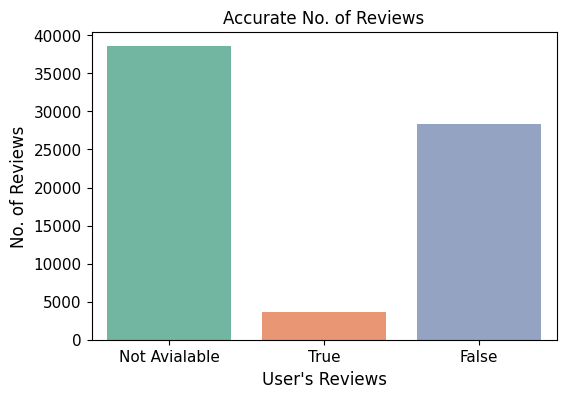

In [116]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='reviews.didPurchase',palette='Set2')
plt.xlabel("User's Reviews", fontsize=12)
plt.ylabel("No. of Reviews", fontsize=12)
plt.title('Accurate No. of Reviews', fontsize=12)
plt.tick_params(labelsize=11, axis='both')
plt.show()

**True reviews are less in number and as you can see poeple who didn't even purchase the product has provided reviews these are all fake reviews which are much higher than those who have purchased and provided the review**.

### Wordcloud

In [117]:
from wordcloud import WordCloud, STOPWORDS

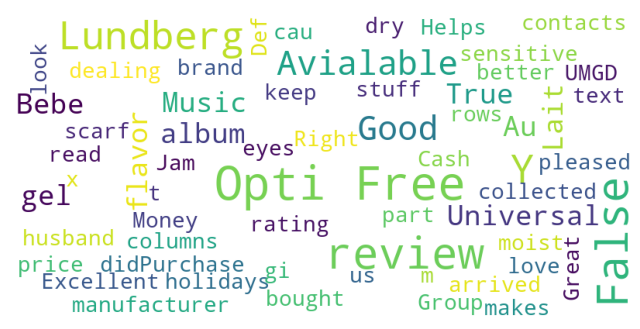

In [118]:
stopwords = set(STOPWORDS)
def wordcloud(data, title = None):
    wordcloud = WordCloud(
        background_color='white',
        stopwords=stopwords,
        max_words=250,
        max_font_size=30,
        scale=2,
        random_state=5 
).generate(str(df))

    fig = plt.figure(1, figsize=(8,8 ))
    plt.axis('off')
    if title: 
        fig.suptitle(title, fontsize=20)
        fig.subplots_adjust(top=2.3)
    plt.imshow(wordcloud)
    plt.show()

wordcloud(df['reviews.text'])

### Feature Transformation

In [119]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

In [120]:
data=df['reviews.text']
train_data=df['reviews.text']
y_target=df['reviews.rating'].map({1:'Unhappy',2:'Unhappy',3:'Ok',4:'Happy',5:'Happy'})

In [121]:
vectorize_word = TfidfVectorizer(sublinear_tf=True,strip_accents='unicode',analyzer='word',token_pattern=r'\w{1,}',stop_words='english',ngram_range=(1, 1),max_features=10000)
vectorize_word.fit(data)
train_features_word = vectorize_word.transform(train_data)

In [122]:
vectorize_char = TfidfVectorizer(sublinear_tf=True,strip_accents='unicode',analyzer='char',stop_words='english',ngram_range=(2, 6),max_features=50000)
vectorize_char.fit(data)
train_features_char = vectorize_char.transform(train_data)
train_features = hstack([train_features_char, train_features_word])

In [123]:
from sklearn.model_selection import train_test_split

In [124]:
X_train, X_test, y_train, y_test = train_test_split(train_features, y_target,test_size=0.3,random_state=101,shuffle=True)

In [125]:
models = {}
results = []

### Logistic  Model:

In [126]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [127]:
lr = LogisticRegression(random_state=101, max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=101)

In [128]:
y_pred = lr.predict(X_test)

In [129]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9100056689342404
              precision    recall  f1-score   support

       Happy       0.93      0.99      0.96     18204
          Ok       0.50      0.18      0.26      1307
     Unhappy       0.82      0.64      0.72      1657

    accuracy                           0.91     21168
   macro avg       0.75      0.60      0.65     21168
weighted avg       0.89      0.91      0.89     21168



#### Testing the model with Random text 

In [130]:
sample_texts = [
    "This laptop is amazing! Super fast processor and battery lasts all day. Best purchase ever!", 
    "The headphones broke after two weeks. Sound quality is mediocre at best. Waste of money.",
    "The book arrived on time and in good condition. It's okay, nothing special." 
]
def predict_sentiment(text, char_vectorizer, word_vectorizer, model):
    char_features = char_vectorizer.transform([text])
    word_features = word_vectorizer.transform([text])
    stacked_features = hstack([char_features, word_features])
    prediction = model.predict(stacked_features)[0]
    return prediction
    
for i, text in enumerate(sample_texts, 1):
    pred = predict_sentiment(text, vectorize_char, vectorize_word, lr)
    print(f"Sample {i}: '{text[:50]}...' → Predicted: **{pred}**")

# Optional: Get probabilities for all classes
# probs = lr.predict_proba(stacked_features)[0]
# print("Probabilities:", dict(zip(lr.classes_, probs)))

Sample 1: 'This laptop is amazing! Super fast processor and b...' → Predicted: **Happy**
Sample 2: 'The headphones broke after two weeks. Sound qualit...' → Predicted: **Unhappy**
Sample 3: 'The book arrived on time and in good condition. It...' → Predicted: **Happy**


### SVC Model

In [131]:
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

In [132]:
lsvm = LinearSVC(class_weight='balanced')
lsvm = lsvm.fit(X_train,y_train)

In [133]:
y_pred_svm = lsvm.predict(X_test)

In [134]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8996598639455783
              precision    recall  f1-score   support

       Happy       0.95      0.95      0.95     18204
          Ok       0.38      0.38      0.38      1307
     Unhappy       0.75      0.71      0.73      1657

    accuracy                           0.90     21168
   macro avg       0.69      0.68      0.69     21168
weighted avg       0.90      0.90      0.90     21168



### Random Forest Classifier Model 

In [135]:
from sklearn.ensemble import RandomForestClassifier

In [136]:
rf = RandomForestClassifier(n_estimators=100, random_state=101, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=101)

In [137]:
y_pred_rf = rf.predict(X_test)

In [138]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
# Feature importance: print(rf.feature_importances_[:10])  # Top 10 words/chars

Random Forest Accuracy: 0.9001795162509448
              precision    recall  f1-score   support

       Happy       0.90      1.00      0.95     18204
          Ok       0.91      0.12      0.21      1307
     Unhappy       0.90      0.46      0.61      1657

    accuracy                           0.90     21168
   macro avg       0.90      0.52      0.59     21168
weighted avg       0.90      0.90      0.87     21168



### Multinomial Naive Bayes

In [139]:
from sklearn.naive_bayes import MultinomialNB

In [140]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

In [141]:
y_pred_nb = nb.predict(X_test)

In [142]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8693310657596371
              precision    recall  f1-score   support

       Happy       0.94      0.93      0.93     18204
          Ok       0.34      0.22      0.27      1307
     Unhappy       0.53      0.72      0.61      1657

    accuracy                           0.87     21168
   macro avg       0.60      0.63      0.60     21168
weighted avg       0.87      0.87      0.87     21168



### XGBoost 

In [143]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [144]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_target)

In [145]:
X_train1, X_test1, y_train1, y_test_encoded1 = train_test_split(
    train_features, y_encoded, test_size=0.3, random_state=101, shuffle=True
)

In [146]:
xgb = XGBClassifier(random_state=101, n_estimators=100, use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train1, y_train1)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [147]:
y_pred_encoded = xgb.predict(X_test1)
y_pred = le.inverse_transform(y_pred_encoded)  
y_test = le.inverse_transform(y_test_encoded1)

In [148]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

XGBoost Accuracy: 0.9083522297808012
              precision    recall  f1-score   support

       Happy       0.92      0.99      0.95     18204
          Ok       0.60      0.16      0.26      1307
     Unhappy       0.84      0.60      0.70      1657

    accuracy                           0.91     21168
   macro avg       0.79      0.58      0.64     21168
weighted avg       0.89      0.91      0.89     21168

